<a href="https://colab.research.google.com/github/PapiDrago/euro-coin-classification/blob/main/coin_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
!cp -r '/content/drive/MyDrive/260617-coins' '/content/euro-coins/'


Mounted at /content/drive/


In [ ]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


['002', '010', '100', '010', '005', '050', '001', '200', '200', '002', '050', '001', '010', '020', '050', '010']
torch.Size([16, 3, 32, 32])


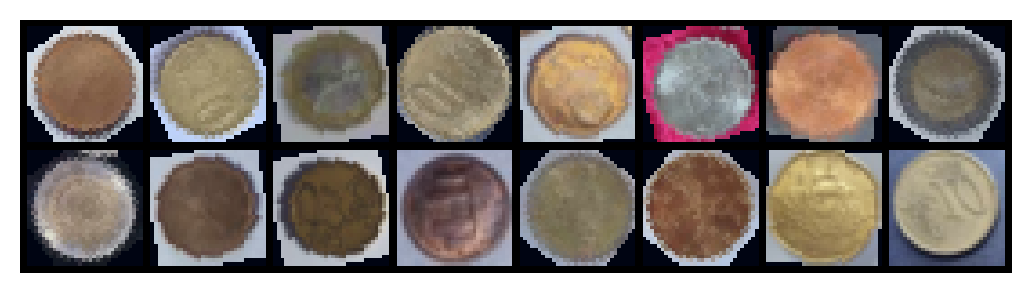

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt

INPUT_HEIGHT_SIZE = 32
INPUT_WIDTH_SIZE = 32
BATCH_SIZE = 16

train_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((INPUT_HEIGHT_SIZE, INPUT_WIDTH_SIZE)),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomRotation(180),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
])

test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((INPUT_HEIGHT_SIZE, INPUT_WIDTH_SIZE)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
])

train_set = torchvision.datasets.ImageFolder("/content/euro-coins/train/", transform=train_transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=2)

test_set = torchvision.datasets.ImageFolder("/content/euro-coins/test/", transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=2)


images, labels = next(iter(train_loader))
plt.figure(dpi=200)
grid = torchvision.utils.make_grid(images, nrow=8, normalize=True).permute(1, 2, 0)
plt.axis("off")
plt.imshow(grid) # Dovresti denormalizzare prima di plottare.
print([train_set.classes[i] for i in labels]) # Prints the labels.
print(images.shape) # Prints the minibatch size dimensions.

In [ ]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size_1, hidden_size_2, num_classes, dropout_p=0.3):
        super(MLP, self).__init__()

        self.model = nn.Sequential(

            # Hidden layer 1
            nn.Linear(input_size, hidden_size_1),
            nn.BatchNorm1d(hidden_size_1),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            # Hidden layer 2
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.BatchNorm1d(hidden_size_2),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            # Output layer
            nn.Linear(hidden_size_2, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten: (batch, 3, 32, 32) → (batch, 3072)
        return self.model(x)


# Instantiate the model
input_size = INPUT_HEIGHT_SIZE*INPUT_WIDTH_SIZE*3
print(input_size)
model = MLP(
    input_size=input_size,
    hidden_size_1=512,
    hidden_size_2=256,
    num_classes=8         # 8 euro coin classes
)

model.to(DEVICE)

ps = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {ps}")



print(model)

3072
Number of parameters: 1708296
MLP(
  (model): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=8, bias=True)
  )
)


Epoch [1/100] Loss: 1.8352 | Accuracy: 32.62%
Epoch [2/100] Loss: 1.3890 | Accuracy: 51.12%
Epoch [3/100] Loss: 1.2296 | Accuracy: 53.37%
Epoch [4/100] Loss: 1.1197 | Accuracy: 58.38%
Epoch [5/100] Loss: 1.0619 | Accuracy: 60.12%
Epoch [6/100] Loss: 0.9922 | Accuracy: 62.12%
Epoch [7/100] Loss: 0.9876 | Accuracy: 62.12%
Epoch [8/100] Loss: 0.9486 | Accuracy: 63.62%
Epoch [9/100] Loss: 0.9347 | Accuracy: 63.38%
Epoch [10/100] Loss: 0.8902 | Accuracy: 67.25%
Epoch [11/100] Loss: 0.8573 | Accuracy: 66.50%
Epoch [12/100] Loss: 0.8352 | Accuracy: 66.50%
Epoch [13/100] Loss: 0.8286 | Accuracy: 69.75%
Epoch [14/100] Loss: 0.8221 | Accuracy: 67.62%
Epoch [15/100] Loss: 0.7916 | Accuracy: 70.12%
Epoch [16/100] Loss: 0.7725 | Accuracy: 70.12%
Epoch [17/100] Loss: 0.7779 | Accuracy: 71.12%
Epoch [18/100] Loss: 0.7673 | Accuracy: 69.88%
Epoch [19/100] Loss: 0.7715 | Accuracy: 71.75%
Epoch [20/100] Loss: 0.7381 | Accuracy: 71.62%
Epoch [21/100] Loss: 0.7113 | Accuracy: 74.50%
Epoch [22/100] Loss: 0

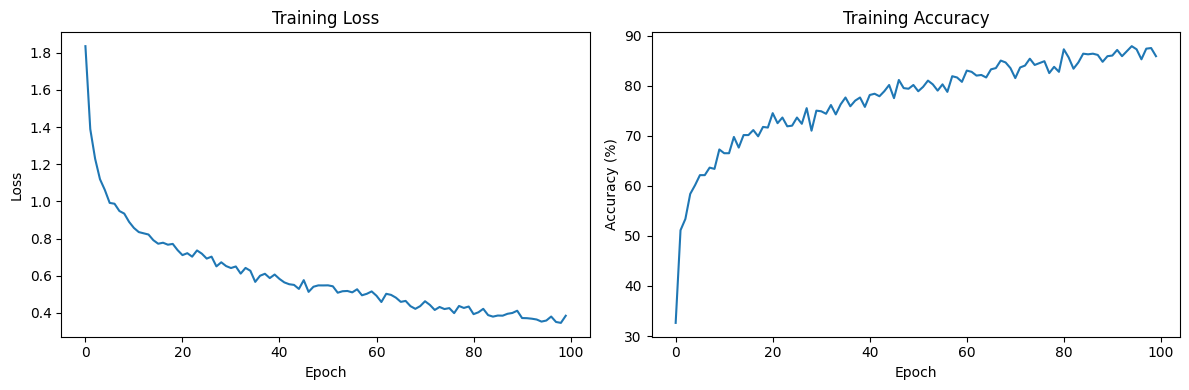

In [ ]:
import matplotlib.pyplot as plt

# --- Hyperparameters ---
EPOCHS = 100
LR = 1e-4
WEIGHT_DECAY = 1e-4

# --- Loss and optimizer ---
loss_fun = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

# --- Tracking metrics ---
train_losses = []
train_accuracies = []

# --- Training loop ---
for epoch in range(EPOCHS):
    model.train()  # sets model to training mode (enables Dropout and BatchNorm)

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Forward pass
        outputs = model(images)
        loss = loss_fun(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track loss and accuracy
        running_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total * 100

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    scheduler.step(epoch_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2.plot(train_accuracies)
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()

In [ ]:
# --- Test evaluation ---
model.eval()  # disables Dropout and BatchNorm training behavior

correct = 0
total = 0

with torch.no_grad():  # disables gradient computation, saves memory and speeds up
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        predicted = outputs.argmax(dim=1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 95.00%


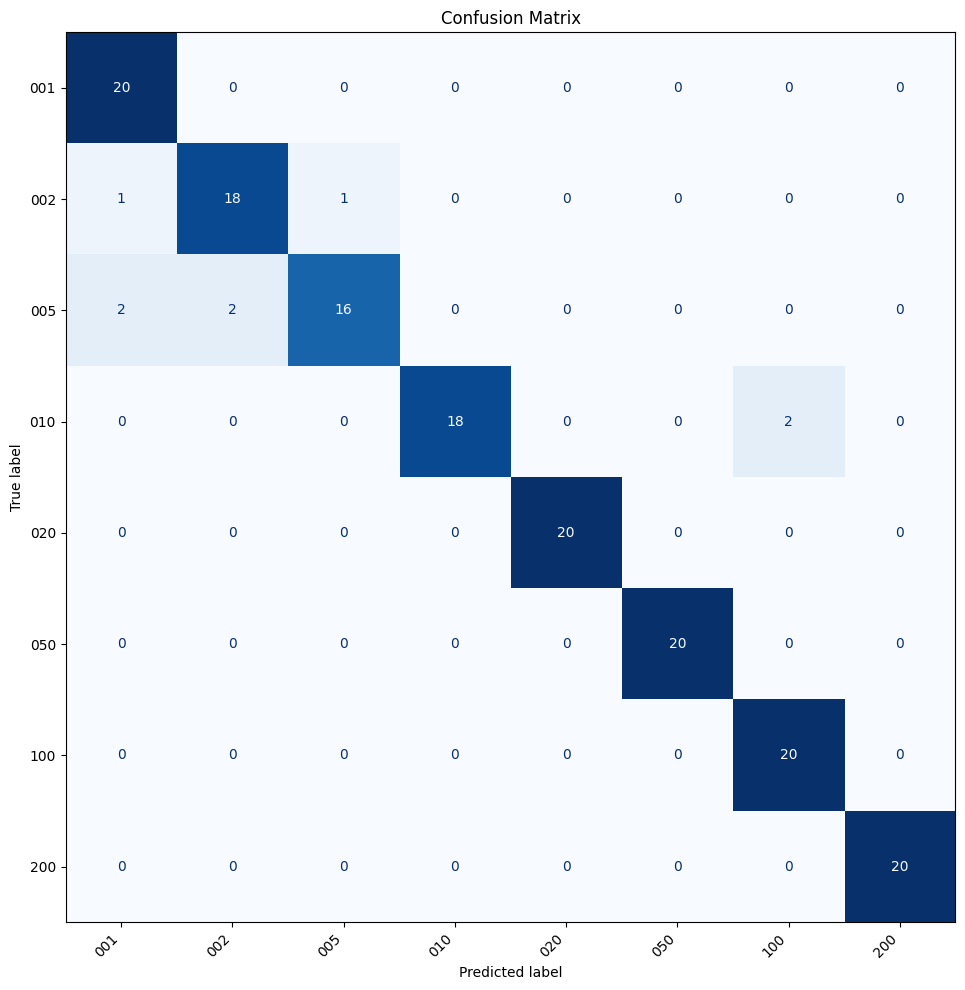

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Collect all predictions and true labels ---
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        predicted = outputs.argmax(dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- Compute and plot confusion matrix ---
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_set.classes)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=8, dropout_p=0.3):
        super(CNN, self).__init__()

        # Convolutional block 1
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # (3, 32, 32) → (32, 32, 32)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                           # (32, 32, 32) → (32, 16, 16)
        )

        # Convolutional block 2
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (32, 16, 16) → (64, 16, 16)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                           # (64, 16, 16) → (64, 8, 8)
        )

        # Convolutional block 3
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# (64, 8, 8) → (128, 8, 8)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                           # (128, 8, 8) → (128, 4, 4)
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),                                # (128, 4, 4) → (2048)
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        return x


# Instantiate
model = CNN(num_classes=8).to(DEVICE)
ps = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {ps}")

Number of parameters: 620808


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s]


Number of trainable parameters: 4104
Epoch [1/100] Loss: 1.9440 | Accuracy: 27.12%
Epoch [2/100] Loss: 1.5174 | Accuracy: 45.62%
Epoch [3/100] Loss: 1.3383 | Accuracy: 51.38%
Epoch [4/100] Loss: 1.2251 | Accuracy: 54.37%
Epoch [5/100] Loss: 1.1429 | Accuracy: 58.38%
Epoch [6/100] Loss: 1.1028 | Accuracy: 60.00%
Epoch [7/100] Loss: 1.0128 | Accuracy: 64.12%
Epoch [8/100] Loss: 0.9992 | Accuracy: 61.88%
Epoch [9/100] Loss: 0.9623 | Accuracy: 64.25%
Epoch [10/100] Loss: 0.9184 | Accuracy: 66.12%
Epoch [11/100] Loss: 0.9341 | Accuracy: 65.75%
Epoch [12/100] Loss: 0.9191 | Accuracy: 66.75%
Epoch [13/100] Loss: 0.8633 | Accuracy: 66.62%
Epoch [14/100] Loss: 0.8483 | Accuracy: 69.50%
Epoch [15/100] Loss: 0.8546 | Accuracy: 67.38%
Epoch [16/100] Loss: 0.8390 | Accuracy: 68.25%
Epoch [17/100] Loss: 0.7932 | Accuracy: 69.88%
Epoch [18/100] Loss: 0.7855 | Accuracy: 71.75%
Epoch [19/100] Loss: 0.8073 | Accuracy: 69.38%
Epoch [20/100] Loss: 0.7793 | Accuracy: 71.00%
Epoch [21/100] Loss: 0.7760 | Ac

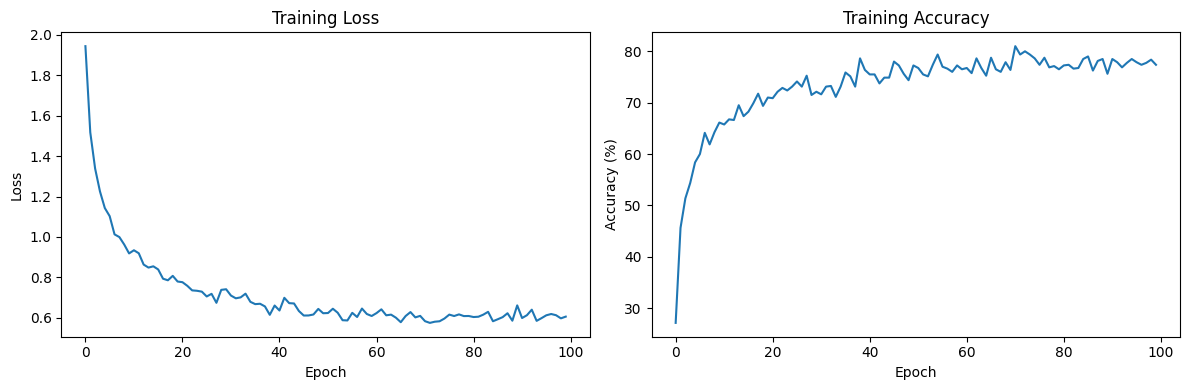

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt
import torch.nn as nn

# Load pretrained ResNet18
weights = torchvision.models.ResNet18_Weights.DEFAULT
model = torchvision.models.resnet18(weights=weights)


# Define transforms
preprocess = weights.transforms()

train_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomRotation(30),
    preprocess
])

BATCH_SIZE = 16

# Rebuild loaders
train_set = torchvision.datasets.ImageFolder("/content/euro-coins/train/", transform=train_transform)
test_set  = torchvision.datasets.ImageFolder("/content/euro-coins/test/",  transform=preprocess)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=2)


# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace and unfreeze only the final layer
model.fc = nn.Linear(model.fc.in_features, 8)  # fc is unfrozen by default
model = model.to(DEVICE)

loss_fun = torch.nn.CrossEntropyLoss()
loss_fun = loss_fun.to(DEVICE)

# --- Hyperparameters ---
EPOCHS = 100  # EPOCHS_PHASE1 = 20  # fast convergence, few parameters
              # EPOCHS_PHASE2 = 50  # slower fine tuning of all layers
LR = 1e-3
WEIGHT_DECAY = 1e-4

# Optimizer only updates the last layer
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"Number of trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")




# --- Tracking metrics ---
train_losses = []
train_accuracies = []

# --- Training loop ---
for epoch in range(EPOCHS):
    model.train()  # sets model to training mode (enables Dropout and BatchNorm)

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Forward pass
        outputs = model(images)
        loss = loss_fun(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track loss and accuracy
        running_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total * 100

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    scheduler.step(epoch_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2.plot(train_accuracies)
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()


Number of trainable parameters: 11180616
Epoch [1/50] Loss: 0.7569 | Accuracy: 70.75%
Epoch [2/50] Loss: 0.4434 | Accuracy: 83.62%
Epoch [3/50] Loss: 0.3198 | Accuracy: 88.12%
Epoch [4/50] Loss: 0.2926 | Accuracy: 89.25%
Epoch [5/50] Loss: 0.2325 | Accuracy: 91.75%
Epoch [6/50] Loss: 0.1759 | Accuracy: 93.00%
Epoch [7/50] Loss: 0.1504 | Accuracy: 94.75%
Epoch [8/50] Loss: 0.1395 | Accuracy: 95.38%
Epoch [9/50] Loss: 0.1033 | Accuracy: 95.88%
Epoch [10/50] Loss: 0.0899 | Accuracy: 97.00%
Epoch [11/50] Loss: 0.0911 | Accuracy: 97.25%
Epoch [12/50] Loss: 0.0950 | Accuracy: 97.12%
Epoch [13/50] Loss: 0.0569 | Accuracy: 98.00%
Epoch [14/50] Loss: 0.0549 | Accuracy: 98.12%
Epoch [15/50] Loss: 0.0733 | Accuracy: 98.00%
Epoch [16/50] Loss: 0.0608 | Accuracy: 98.25%
Epoch [17/50] Loss: 0.0427 | Accuracy: 98.38%
Epoch [18/50] Loss: 0.0348 | Accuracy: 98.75%
Epoch [19/50] Loss: 0.0525 | Accuracy: 98.75%
Epoch [20/50] Loss: 0.0537 | Accuracy: 98.00%
Epoch [21/50] Loss: 0.0527 | Accuracy: 97.88%
Ep

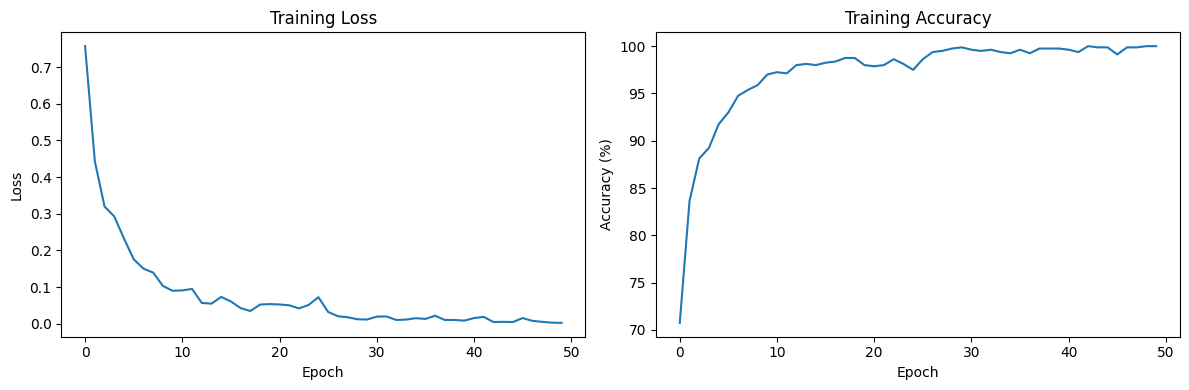

In [ ]:
# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Lower LR for fine tuning — important to avoid overwriting pretrained weights
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"Number of trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

EPOCHS = 50

# --- Tracking metrics ---
train_losses = []
train_accuracies = []

# --- Training loop ---
for epoch in range(EPOCHS):
    model.train()  # sets model to training mode (enables Dropout and BatchNorm)

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Forward pass
        outputs = model(images)
        loss = loss_fun(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track loss and accuracy
        running_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total * 100

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    scheduler.step(epoch_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2.plot(train_accuracies)
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()



In [ ]:
coin_values = torch.tensor([1, 2, 5, 10, 20, 50, 100, 200], device=DEVICE)  # match train_set.classes order!
cost_matrix = (coin_values.unsqueeze(0) - coin_values.unsqueeze(1)).abs().float()

model.eval()
total_cost_argmax = 0.0
total_cost_risk = 0.0
n_samples = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        pred_argmax = outputs.argmax(dim=1)
        risk = probs @ cost_matrix.T
        pred_risk = risk.argmin(dim=1)

        true_values = coin_values[labels]
        argmax_values = coin_values[pred_argmax]
        risk_values = coin_values[pred_risk]

        total_cost_argmax += (true_values - argmax_values).abs().sum().item()
        total_cost_risk += (true_values - risk_values).abs().sum().item()
        n_samples += labels.size(0)

print(f"Mean misclassification cost (argmax):         {total_cost_argmax / n_samples:.2f} cents")
print(f"Mean misclassification cost (risk-minimizing): {total_cost_risk / n_samples:.2f} cents")

Mean misclassification cost (argmax):         1.24 cents
Mean misclassification cost (risk-minimizing): 1.24 cents


In [ ]:
model.eval()
worst_cases = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        pred_argmax = outputs.argmax(dim=1)
        risk = probs @ cost_matrix.T
        pred_risk = risk.argmin(dim=1)

        for i in range(labels.size(0)):
            true_v = coin_values[labels[i]].item()
            argmax_v = coin_values[pred_argmax[i]].item()
            risk_v = coin_values[pred_risk[i]].item()
            cost_argmax = abs(true_v - argmax_v)
            cost_risk = abs(true_v - risk_v)
            if cost_argmax != cost_risk:
                worst_cases.append({
                    'true': true_v, 'argmax_pred': argmax_v, 'risk_pred': risk_v,
                    'cost_argmax': cost_argmax, 'cost_risk': cost_risk
                })

for c in worst_cases:
    print(c)

In [ ]:
print(train_set.classes)
print(test_set.classes)

import collections
print(collections.Counter(train_set.targets))
print(collections.Counter(test_set.targets))

images, labels = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")
print(f"Labels: {labels}")
print(f"Label names: {[train_set.classes[i] for i in labels]}")

# Check what preprocess does
print(preprocess)

['001', '002', '005', '010', '020', '050', '100', '200']
['001', '002', '005', '010', '020', '050', '100', '200']
Counter({0: 100, 1: 100, 2: 100, 3: 100, 4: 100, 5: 100, 6: 100, 7: 100})
Counter({0: 20, 1: 20, 2: 20, 3: 20, 4: 20, 5: 20, 6: 20, 7: 20})
Image batch shape: torch.Size([16, 3, 224, 224])
Labels: tensor([3, 3, 5, 0, 0, 7, 6, 4, 7, 6, 7, 3, 1, 0, 4, 6])
Label names: ['010', '010', '050', '001', '001', '200', '100', '020', '200', '100', '200', '010', '002', '001', '020', '100']
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [ ]:
# Check a sample image size from the dataset before transforms
from PIL import Image
import os

sample_path = next(
    os.path.join(root, f)
    for root, dirs, files in os.walk("/content/euro-coins/train/")
    for f in files if f.endswith('.png')
)
img = Image.open(sample_path)
print(f"Original image size: {img.size}")
print(f"Mode: {img.mode}")

Original image size: (64, 64)
Mode: RGB


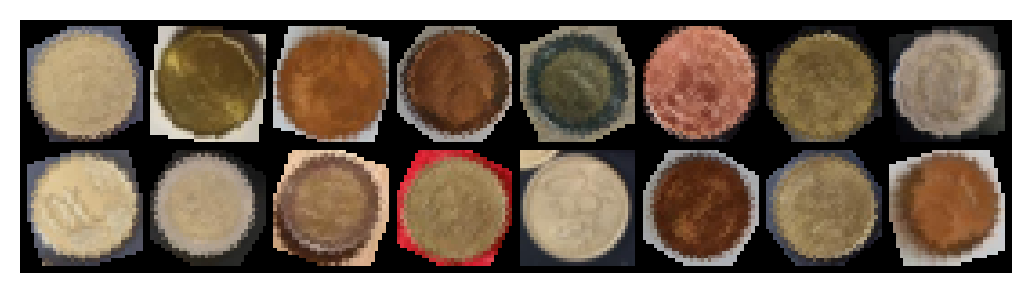

['010', '050', '002', '001', '200', '001', '010', '200', '010', '200', '200', '050', '050', '002', '010', '001']
torch.Size([16, 3, 32, 32])


In [ ]:
import torch
import matplotlib.pyplot as plt
import torchvision

# The ImageNet stats you normalized with
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

images, labels = next(iter(train_loader))

# Denormalize: pixel = (normalized * std) + mean
images_denorm = images * std + mean
images_denorm = torch.clamp(images_denorm, 0, 1)  # clip tiny numerical overflows

plt.figure(dpi=200)
grid = torchvision.utils.make_grid(images_denorm, nrow=8).permute(1, 2, 0)
plt.axis("off")
plt.imshow(grid)
plt.show()

print([train_set.classes[i] for i in labels])
print(images.shape)

{'true': 1, 'argmax_pred': 1, 'risk_pred': 2, 'cost_argmax': 0, 'cost_risk': 1}
{'true': 1, 'argmax_pred': 5, 'risk_pred': 2, 'cost_argmax': 4, 'cost_risk': 1}
{'true': 1, 'argmax_pred': 1, 'risk_pred': 2, 'cost_argmax': 0, 'cost_risk': 1}
{'true': 1, 'argmax_pred': 5, 'risk_pred': 2, 'cost_argmax': 4, 'cost_risk': 1}
{'true': 1, 'argmax_pred': 5, 'risk_pred': 2, 'cost_argmax': 4, 'cost_risk': 1}
{'true': 1, 'argmax_pred': 1, 'risk_pred': 2, 'cost_argmax': 0, 'cost_risk': 1}
{'true': 1, 'argmax_pred': 50, 'risk_pred': 5, 'cost_argmax': 49, 'cost_risk': 4}
{'true': 1, 'argmax_pred': 5, 'risk_pred': 2, 'cost_argmax': 4, 'cost_risk': 1}
{'true': 2, 'argmax_pred': 1, 'risk_pred': 2, 'cost_argmax': 1, 'cost_risk': 0}
{'true': 2, 'argmax_pred': 1, 'risk_pred': 2, 'cost_argmax': 1, 'cost_risk': 0}
{'true': 2, 'argmax_pred': 5, 'risk_pred': 2, 'cost_argmax': 3, 'cost_risk': 0}
{'true': 2, 'argmax_pred': 5, 'risk_pred': 2, 'cost_argmax': 3, 'cost_risk': 0}
{'true': 2, 'argmax_pred': 5, 'risk_pred': 2, 'cost_argmax': 3, 'cost_risk': 0}
{'true': 5, 'argmax_pred': 1, 'risk_pred': 2, 'cost_argmax': 4, 'cost_risk': 3}
{'true': 5, 'argmax_pred': 2, 'risk_pred': 5, 'cost_argmax': 3, 'cost_risk': 0}
{'true': 5, 'argmax_pred': 1, 'risk_pred': 2, 'cost_argmax': 4, 'cost_risk': 3}
{'true': 5, 'argmax_pred': 1, 'risk_pred': 2, 'cost_argmax': 4, 'cost_risk': 3}
{'true': 5, 'argmax_pred': 1, 'risk_pred': 2, 'cost_argmax': 4, 'cost_risk': 3}
{'true': 5, 'argmax_pred': 1, 'risk_pred': 2, 'cost_argmax': 4, 'cost_risk': 3}
{'true': 5, 'argmax_pred': 1, 'risk_pred': 2, 'cost_argmax': 4, 'cost_risk': 3}
{'true': 20, 'argmax_pred': 50, 'risk_pred': 20, 'cost_argmax': 30, 'cost_risk': 0}
{'true': 50, 'argmax_pred': 1, 'risk_pred': 5, 'cost_argmax': 49, 'cost_risk': 45}
{'true': 50, 'argmax_pred': 100, 'risk_pred': 50, 'cost_argmax': 50, 'cost_risk': 0}